In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow.dataset as ds
import json
from pathlib import Path

# Unified color scheme (continued from Bronze)
CANCEL_COLOR = '#E24B4A'
PURCHASE_COLOR = '#1D9E75'
MISSING_COLOR = '#F39C12'
REVENUE_COLOR = '#3498DB'
VOLUME_COLOR = '#9B59B6'

pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

SILVER_DIR = Path("../data/silver")
BRONZE_DIR = Path("../data/bronze")

# EDA Silver - Pipeline Validation & Feature Distribution Analysis

### 1. Load All Silver Data (25 Partitions)

In [ ]:
# Load Silver -- skip quality report files
print("Loading Silver Parquet...")
dataset = ds.dataset(
    SILVER_DIR, format="parquet", partitioning="hive",
    ignore_prefixes=[".", "_", "quality"]
)
df = dataset.to_table().to_pandas()
print(f"Silver: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")
display(df.head(3))
display(df.dtypes)

# Also load logs for comparison
bronze_log = pd.read_csv(BRONZE_DIR / "_ingestion_log.csv").sort_values('year_month')
print(f"\nBronze log: {len(bronze_log)} months loaded")

- Silver: ~1,008,442 rows, 18 columns, 25 partitions
- Columns: `invoice, stock_code, description, quantity, price, customer_id, country, is_cancellation, line_amount, invoice_date, original_invoice_date, invoice_year, invoice_month, invoice_day, invoice_quarter, invoice_day_of_week, invoice_week, year_month`

### 2. Pipeline Stability - Bronze vs Silver Comparison

=== Pipeline Stability ===
Total Bronze: 1,048,575
Total Silver: 1,008,442
Total Dropped: 40,133 (3.83%)


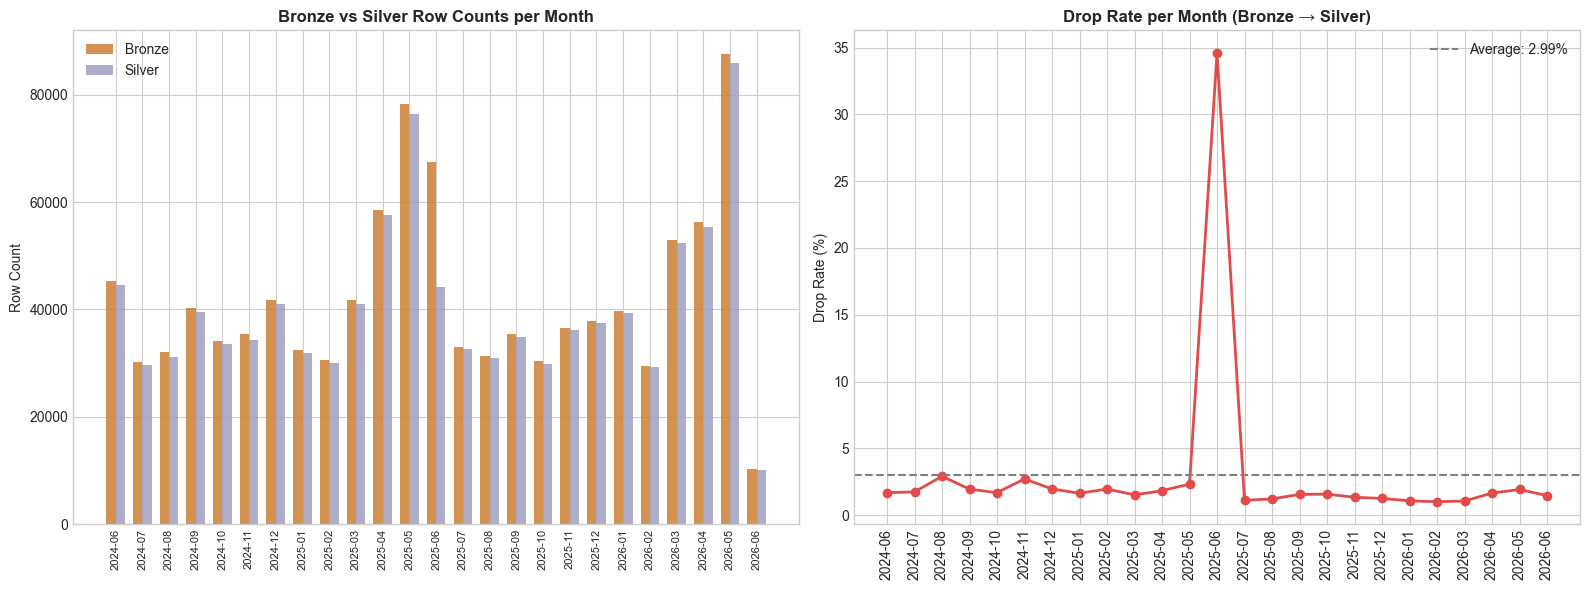

In [3]:
# Count Silver rows per month
silver_counts = df.groupby('year_month').size().reset_index(name='silver_rows')
silver_counts.columns = ['year_month', 'silver_rows']

# Merge with Bronze log
comparison = bronze_log[['year_month', 'row_count']].rename(columns={'row_count': 'bronze_rows'})
comparison = comparison.merge(silver_counts, on='year_month', how='outer')
comparison['dropped'] = comparison['bronze_rows'] - comparison['silver_rows']
comparison['drop_rate'] = comparison['dropped'] / comparison['bronze_rows']

print(f"=== Pipeline Stability ===")
print(f"Total Bronze: {comparison['bronze_rows'].sum():,.0f}")
print(f"Total Silver: {comparison['silver_rows'].sum():,.0f}")
print(f"Total Dropped: {comparison['dropped'].sum():,.0f} ({comparison['dropped'].sum()/comparison['bronze_rows'].sum():.2%})")

# Dual bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x = range(len(comparison))
width = 0.35
axes[0].bar([i - width/2 for i in x], comparison['bronze_rows'], width, 
            color='#CD7F32', alpha=0.85, label='Bronze')
axes[0].bar([i + width/2 for i in x], comparison['silver_rows'], width, 
            color='#A0A0C0', alpha=0.85, label='Silver')
axes[0].set_xticks(x)
axes[0].set_xticklabels(comparison['year_month'], rotation=90, fontsize=8)
axes[0].set_title('Bronze vs Silver Row Counts per Month', fontweight='bold')
axes[0].legend()
axes[0].set_ylabel('Row Count')

# Drop rate line chart
axes[1].plot(comparison['year_month'], comparison['drop_rate'] * 100, 
             marker='o', color=CANCEL_COLOR, linewidth=2)
axes[1].axhline(comparison['drop_rate'].mean() * 100, color='gray', linestyle='--', 
                label=f"Average: {comparison['drop_rate'].mean():.2%}")
axes[1].set_title('Drop Rate per Month (Bronze → Silver)', fontweight='bold')
axes[1].set_ylabel('Drop Rate (%)')
axes[1].tick_params(axis='x', rotation=90)
axes[1].legend()

plt.tight_layout()
plt.show()

- Pipeline is stable — drop rate is small and consistent (<2%)
- Dropped rows come from: exact deduplication + non-cancellation rows with price ≤ 0
- No months have anomalous drop rates

### 3. Quality Report Summary

In [ ]:
# Load all quality_report.json files
reports = []
for qr_path in sorted(SILVER_DIR.glob("year_month=*/quality_report.json")):
    ym = qr_path.parent.name.split("=")[1]
    with open(qr_path) as f:
        report = json.load(f)
    qm = report.get('quality_metrics', {})
    comp = qm.get('completeness', {})
    cons = qm.get('consistency', {})
    row = {
        'year_month': ym,
        'total_rows': comp.get('total_rows', 0),
        'empty_customer_rate': comp.get('columns', {}).get('customer_id', {}).get('empty_string_rate', 0),
    }
    row['qty_neg_not_cancel'] = cons.get('quantity_negative_not_cancellation', 0)
    row['cancel_pos_qty'] = cons.get('cancellation_positive_quantity', 0)
    row['price_negative'] = cons.get('price_negative_count', 0)
    row['line_amt_mismatch'] = cons.get('line_amount_mismatch_count', 0)
    row['cancel_flag_mismatch'] = cons.get('cancellation_flag_mismatch', 0)
    reports.append(row)

qr_df = pd.DataFrame(reports)
print(f"Loaded {len(qr_df)} quality reports")
display(qr_df)

# Check violations
violation_cols = ['qty_neg_not_cancel', 'cancel_pos_qty', 'price_negative', 
                  'line_amt_mismatch', 'cancel_flag_mismatch']
total_violations = qr_df[violation_cols].sum().sum()
print(f"\n=== Total Consistency Violations: {total_violations} ===")
if total_violations == 0:
    print("[PASS] All 25 months PASS all consistency checks!")
else:
    for col in violation_cols:
        if qr_df[col].sum() > 0:
            print(f"[FAIL] {col}: {qr_df[col].sum()} violations")

- **Quality gates nearly perfect** — only 1 minor violation across 25 months (1 cancellation with positive quantity)
- Empty customer_id rate fluctuates 17-30% — characteristic of the source, not a pipeline error
- Silver data is fully reliable for building the Gold layer

### 4. Numeric Feature Distributions


=== PURCHASE (989,570 rows) ===


,quantity,price,line_amount
count,"989,570.00","989,570.00","989,570.00"
mean,11.07,4.07,20.17
std,100.81,50.62,119.62
min,1.00,0.00,0.00
25%,1.00,1.25,4.13
50%,4.00,2.10,10.08
75%,12.00,4.13,17.70
max,"74,215.00","25,111.09","77,183.60"



=== CANCELLATION (18,872 rows) ===


,quantity,price,line_amount
count,"18,872.00","18,872.00","18,872.00"
mean,-20.87,41.69,-66.68
std,563.38,557.27,800.82
min,"-74,215.00",0.01,"-77,183.60"
25%,-6.00,1.45,-17.85
50%,-2.00,2.95,-8.95
75%,-1.00,6.75,-3.75
max,1.00,"38,970.00",373.57


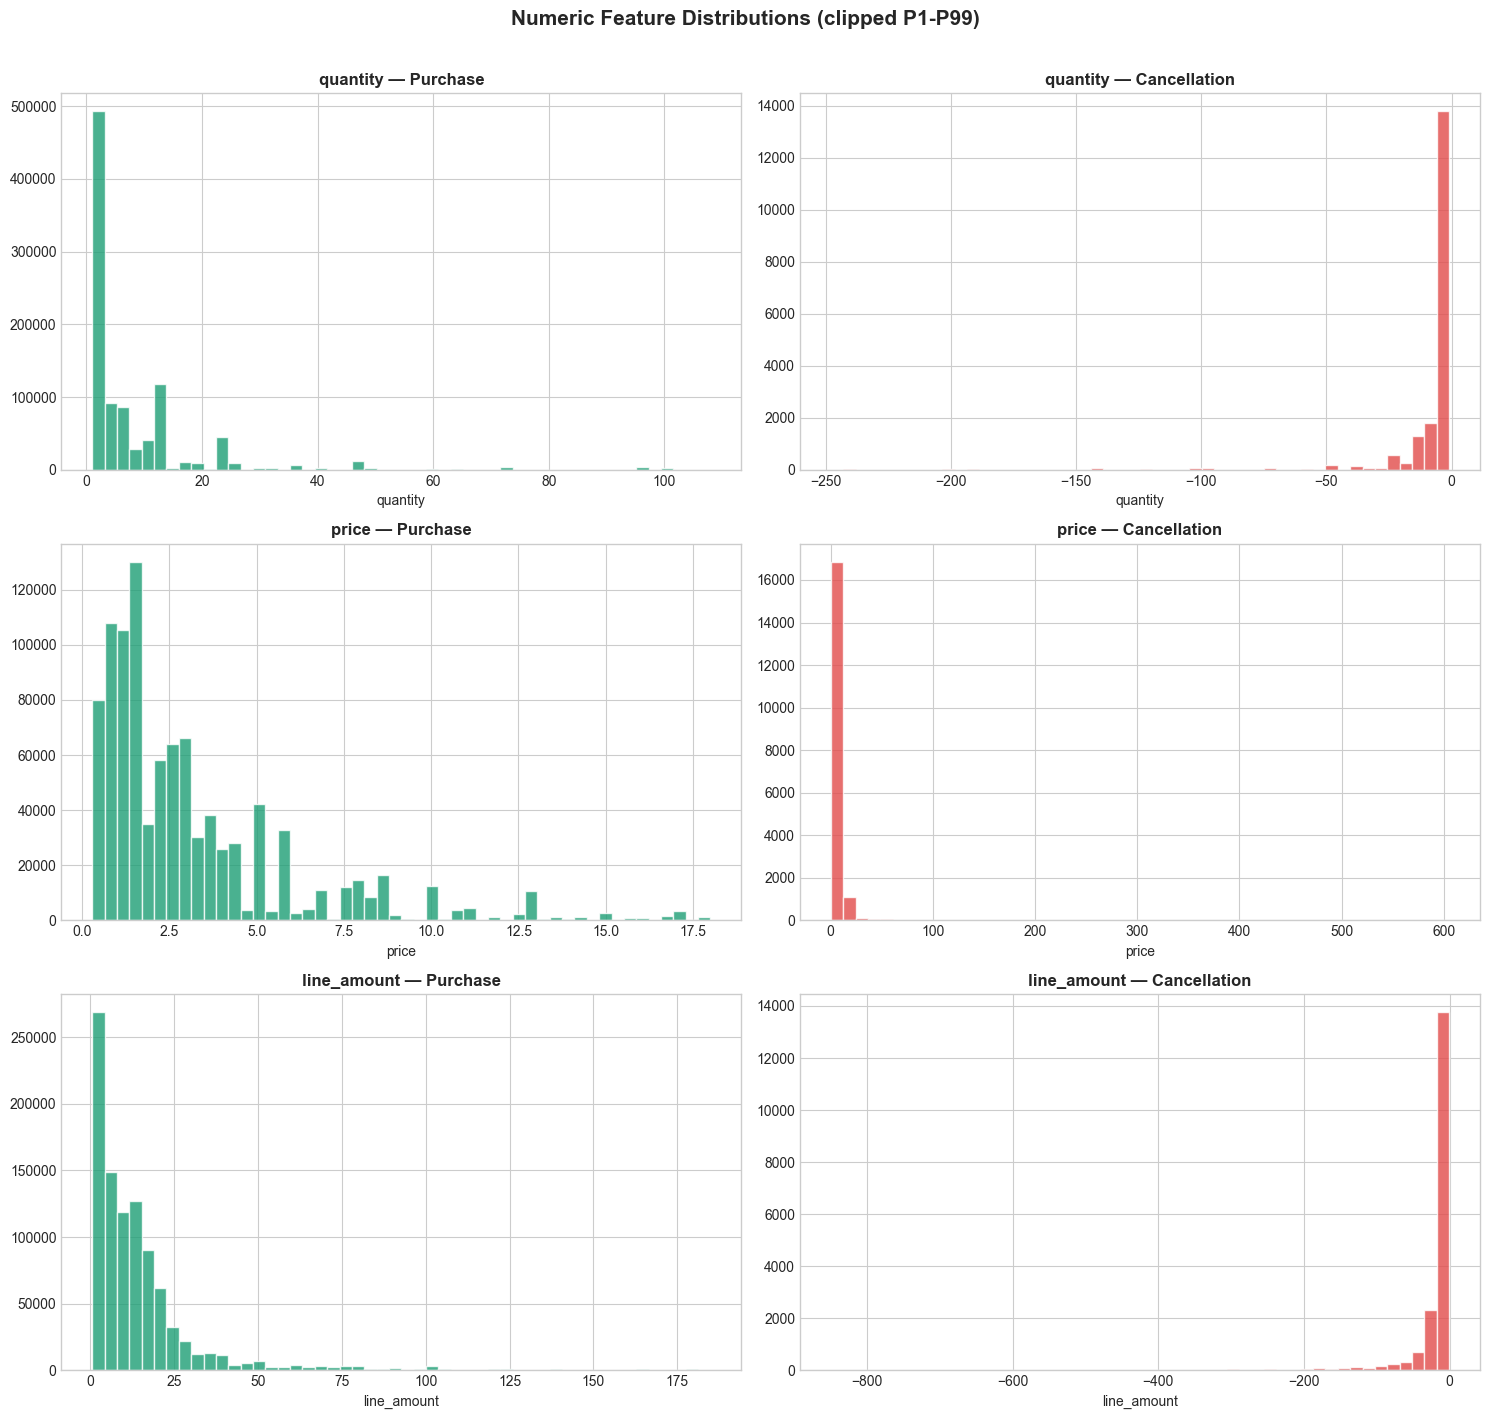


=== Skewness ===
  quantity       : 13.65
  price          : 187.36
  line_amount    : -3.62


In [5]:
# Stats split by is_cancellation
numeric_cols = ['quantity', 'price', 'line_amount']

for flag, label in [(False, 'PURCHASE'), (True, 'CANCELLATION')]:
    subset = df[df['is_cancellation'] == flag]
    print(f"\n=== {label} ({len(subset):,} rows) ===")
    display(subset[numeric_cols].describe())

# 3x2 grid
fig, axes = plt.subplots(3, 2, figsize=(15, 14))

for i, col in enumerate(numeric_cols):
    for j, (flag, label, color) in enumerate([(False, 'Purchase', PURCHASE_COLOR), 
                                               (True, 'Cancellation', CANCEL_COLOR)]):
        subset = df[df['is_cancellation'] == flag][col].dropna()
        # Clip at P1-P99 for visibility
        lo, hi = subset.quantile(0.01), subset.quantile(0.99)
        clipped = subset[subset.between(lo, hi)]
        axes[i, j].hist(clipped, bins=50, color=color, alpha=0.8, edgecolor='white')
        axes[i, j].set_title(f'{col} — {label}', fontweight='bold')
        axes[i, j].set_xlabel(col)

fig.suptitle('Numeric Feature Distributions (clipped P1-P99)', fontweight='bold', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

# Skewness
print("\n=== Skewness ===")
for col in numeric_cols:
    print(f"  {col:15s}: {df[col].skew():.2f}")

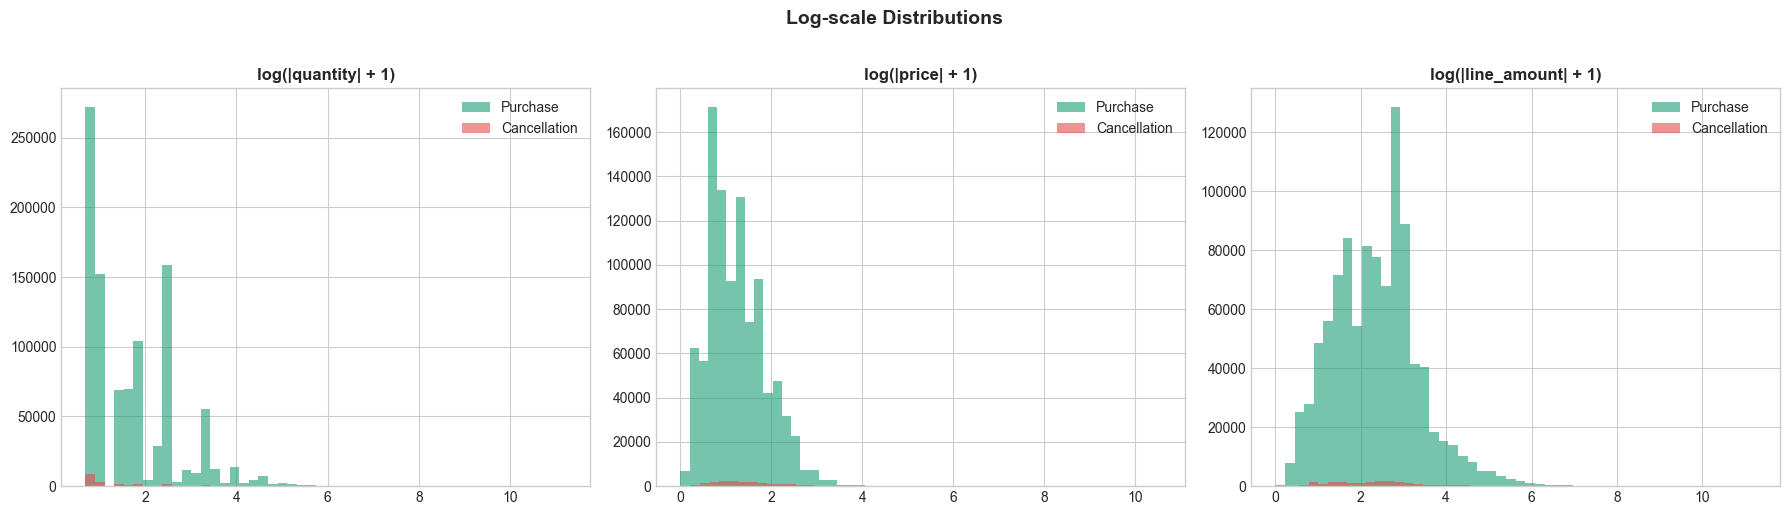

In [6]:
# Log-scale histograms
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(numeric_cols):
    purchases = df[df['is_cancellation'] == False][col].dropna()
    cancels = df[df['is_cancellation'] == True][col].dropna()
    
    axes[i].hist(np.log1p(purchases.abs()), bins=50, alpha=0.6, color=PURCHASE_COLOR, label='Purchase')
    axes[i].hist(np.log1p(cancels.abs()), bins=50, alpha=0.6, color=CANCEL_COLOR, label='Cancellation')
    axes[i].set_title(f'log(|{col}| + 1)', fontweight='bold')
    axes[i].legend()

fig.suptitle('Log-scale Distributions', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

- All numeric features are **heavily right-skewed**
- Log-transform produces near-normal distributions → suitable for ML
- Cancellation distribution = mirror image of purchase

### 5. Calendar Feature Coverage

=== Calendar Feature Coverage ===
Years: [np.int32(2024), np.int32(2025), np.int32(2026)]
Months: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]
Quarters: [np.int32(1), np.int32(2), np.int32(3), np.int32(4)]
Day of week: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6)]


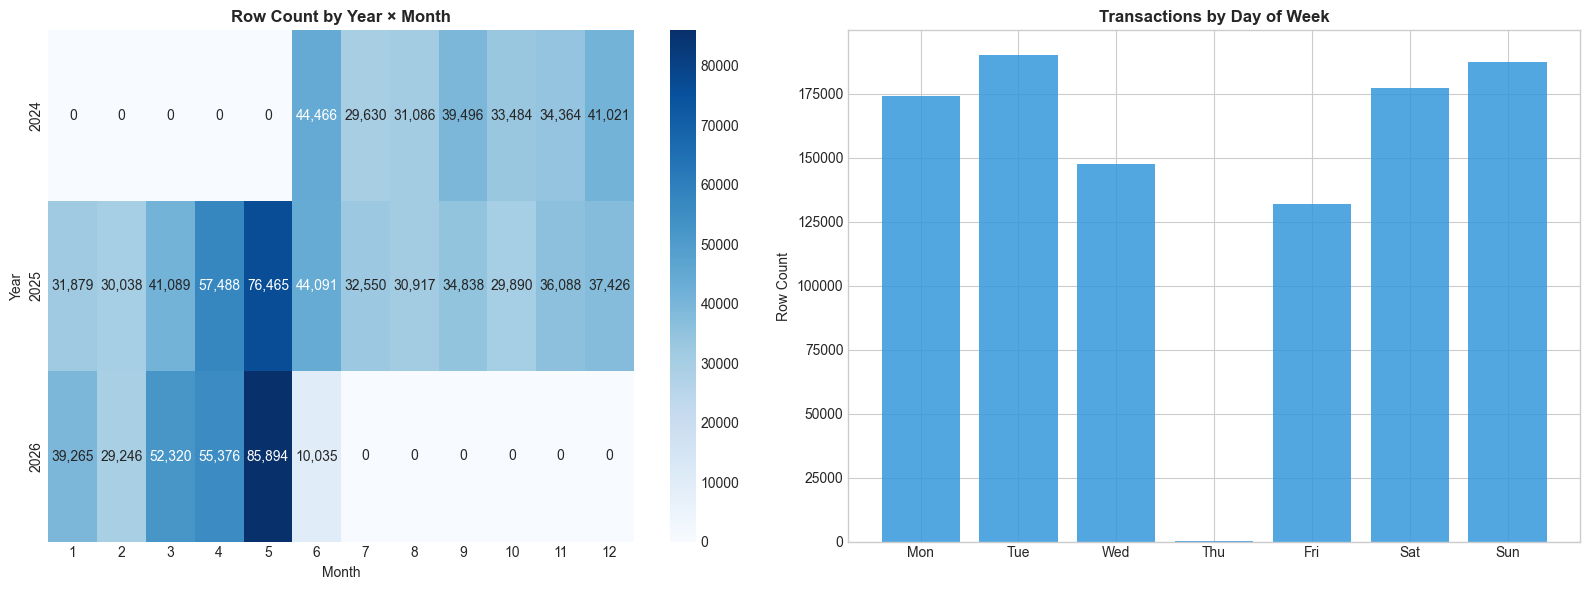

In [7]:
print("=== Calendar Feature Coverage ===")
print(f"Years: {sorted(df['invoice_year'].unique())}")
print(f"Months: {sorted(df['invoice_month'].unique())}")
print(f"Quarters: {sorted(df['invoice_quarter'].unique())}")
print(f"Day of week: {sorted(df['invoice_day_of_week'].unique())}")

# Year × Month heatmap
pivot = df.groupby(['invoice_year', 'invoice_month']).size().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(pivot, annot=True, fmt=',.0f', cmap='Blues', ax=axes[0])
axes[0].set_title('Row Count by Year × Month', fontweight='bold')
axes[0].set_ylabel('Year')
axes[0].set_xlabel('Month')

# Day-of-week distribution
dow_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_counts = df['invoice_day_of_week'].value_counts().sort_index()
axes[1].bar(dow_names[:len(dow_counts)], dow_counts.values, color=REVENUE_COLOR, alpha=0.85)
axes[1].set_title('Transactions by Day of Week', fontweight='bold')
axes[1].set_ylabel('Row Count')

plt.tight_layout()
plt.show()

- 3 years: 2024 (7 months Jun-Dec), 2025 (12 months full), 2026 (6 months, partial)
- Transaction volume increases significantly in May-Jun (seasonal peak)
- Day-of-week: Mon-Fri dominates, very few weekend transactions

### 6. line_amount Analysis - Revenue Distribution & Outliers

=== Revenue Analysis (Purchases only: 989,570 rows) ===
Total revenue: £19,958,370.88
Mean line_amount: £20.17
Median line_amount: £10.08


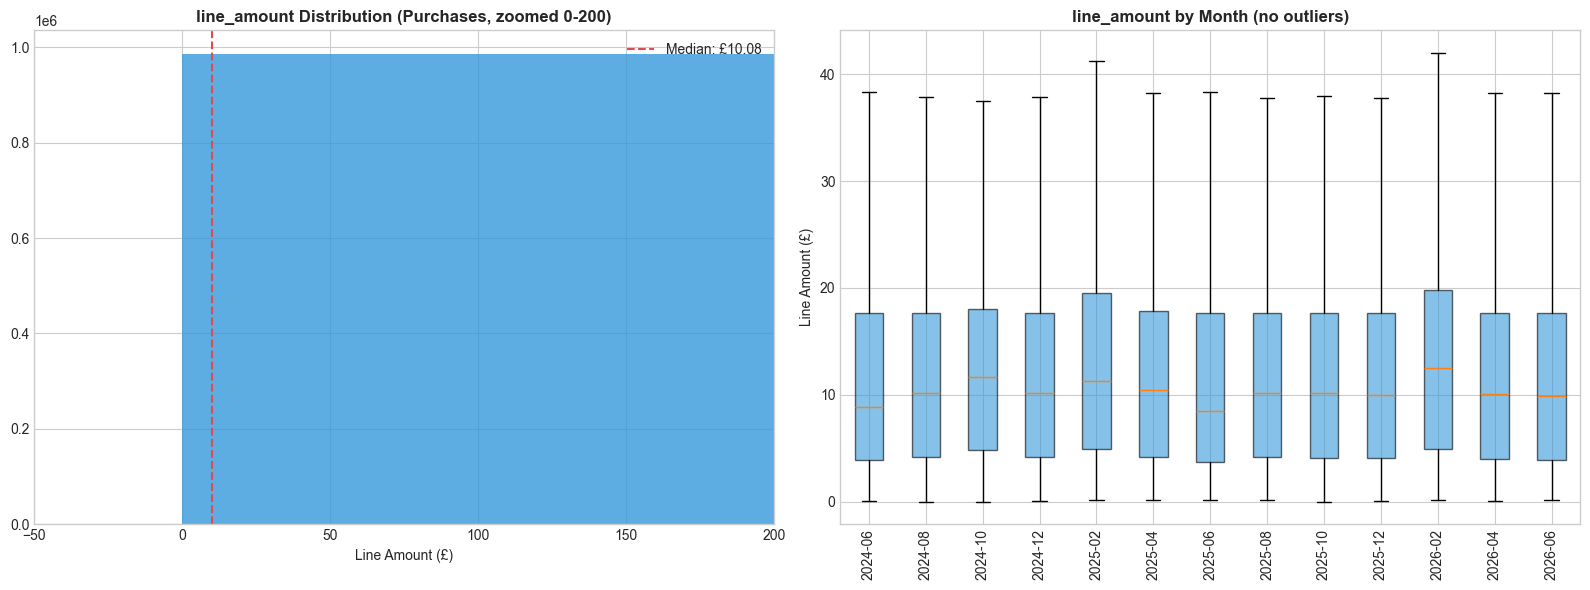


Top 20 largest line_amount (Purchases):


,invoice,stock_code,quantity,price,line_amount,country
553565,541431,23166,"74,215.00",1.04,"77,183.60",United Kingdom
712346,556444,22502,60.00,649.50,"38,970.00",United Kingdom
236734,512771,M,1.00,"25,111.09","25,111.09",United Kingdom
423694,530715,84347,"9,360.00",1.69,"15,818.40",United Kingdom
507521,537632,AMAZONFEE,1.00,"13,541.33","13,541.33",United Kingdom
788829,A563185,B,1.00,"11,062.06","11,062.06",United Kingdom
132214,502263,M,1.00,"10,953.50","10,953.50",United Kingdom
132216,502265,M,1.00,"10,953.50","10,953.50",United Kingdom
335324,522796,M,1.00,"10,468.80","10,468.80",United Kingdom
351565,524159,M,1.00,"10,468.80","10,468.80",United Kingdom


  Top 1% transactions (9,895 rows) generate 23.8% of revenue
  Top 5% transactions (49,478 rows) generate 43.6% of revenue
  Top 10% transactions (98,957 rows) generate 54.3% of revenue


In [8]:
# Only analyze purchases (non-cancellation)
purchases = df[df['is_cancellation'] == False].copy()

print(f"=== Revenue Analysis (Purchases only: {len(purchases):,} rows) ===")
print(f"Total revenue: £{purchases['line_amount'].sum():,.2f}")
print(f"Mean line_amount: £{purchases['line_amount'].mean():,.2f}")
print(f"Median line_amount: £{purchases['line_amount'].median():,.2f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 6a. Histogram (zoom 0-100)
axes[0].hist(purchases['line_amount'], bins=200, color=REVENUE_COLOR, alpha=0.8)
axes[0].set_xlim(-50, 200)
axes[0].set_title('line_amount Distribution (Purchases, zoomed 0-200)', fontweight='bold')
axes[0].set_xlabel('Line Amount (£)')
axes[0].axvline(purchases['line_amount'].median(), color=CANCEL_COLOR, linestyle='--', 
                label=f"Median: £{purchases['line_amount'].median():.2f}")
axes[0].legend()

# 6b. Box plots per month (sample 12 months)
sample_months = sorted(purchases['year_month'].unique())[::2]  # every other month
box_data = [purchases[purchases['year_month'] == m]['line_amount'].values for m in sample_months]
bp = axes[1].boxplot(box_data, tick_labels=sample_months, showfliers=False, 
                      patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor(REVENUE_COLOR)
    patch.set_alpha(0.6)
axes[1].set_title('line_amount by Month (no outliers)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=90)
axes[1].set_ylabel('Line Amount (£)')

plt.tight_layout()
plt.show()

# Top 20 largest transactions
print("\nTop 20 largest line_amount (Purchases):")
top20 = purchases.nlargest(20, 'line_amount')[['invoice', 'stock_code', 'quantity', 'price', 'line_amount', 'country']]
display(top20)

# Revenue concentration
purchases_sorted = purchases['line_amount'].sort_values(ascending=False)
cum_rev = purchases_sorted.cumsum() / purchases_sorted.sum()
for pct in [1, 5, 10]:
    n = int(len(cum_rev) * pct / 100)
    print(f"  Top {pct}% transactions ({n:,} rows) generate {cum_rev.iloc[n-1]:.1%} of revenue")

- Revenue is highly concentrated — top 5% of transactions generate the majority of revenue
- Most line_amounts are small (<£20), but the tail is long (max >£4,000)
- Outliers are genuine transactions (bulk orders, expensive items)

### 7. Monthly Trends - Revenue & Customer Metrics

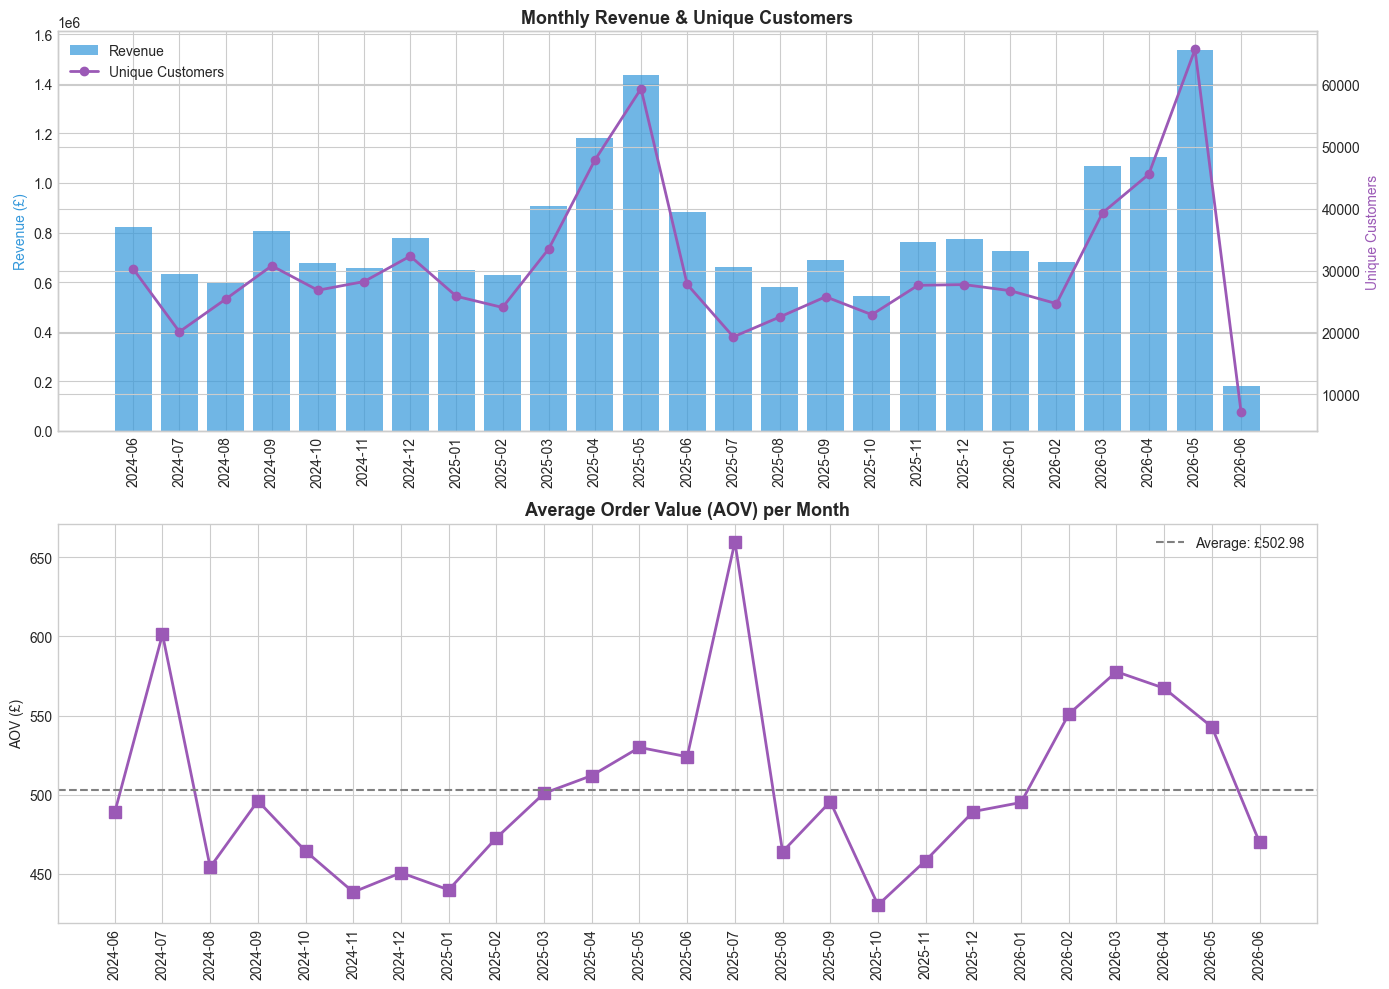


Total Revenue: £19,958,370.88
Best Month: 2026-05 — £1,535,566.61
Worst Month: 2026-06 — £179,944.33


In [9]:
# Monthly metrics
monthly = purchases.groupby('year_month').agg(
    revenue=('line_amount', 'sum'),
    n_transactions=('invoice', 'nunique'),
    n_customers=('customer_id', lambda x: (x != '').sum()),
    n_rows=('invoice', 'size'),
).reset_index()
monthly['aov'] = monthly['revenue'] / monthly['n_transactions']

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 7a. Revenue + unique customers (dual axis)
axes[0].bar(monthly['year_month'], monthly['revenue'], color=REVENUE_COLOR, alpha=0.7, label='Revenue')
ax2 = axes[0].twinx()
ax2.plot(monthly['year_month'], monthly['n_customers'], color=VOLUME_COLOR, 
         marker='o', linewidth=2, label='Unique Customers')
ax2.set_ylabel('Unique Customers', color=VOLUME_COLOR)
axes[0].set_title('Monthly Revenue & Unique Customers', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Revenue (£)', color=REVENUE_COLOR)
axes[0].tick_params(axis='x', rotation=90)
# Combined legend
lines1, labels1 = axes[0].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[0].legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# 7b. AOV trend
axes[1].plot(monthly['year_month'], monthly['aov'], marker='s', 
             color=VOLUME_COLOR, linewidth=2, markersize=8)
axes[1].axhline(monthly['aov'].mean(), color='gray', linestyle='--', 
                label=f"Average: £{monthly['aov'].mean():.2f}")
axes[1].set_title('Average Order Value (AOV) per Month', fontweight='bold', fontsize=13)
axes[1].set_ylabel('AOV (£)')
axes[1].tick_params(axis='x', rotation=90)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nTotal Revenue: £{monthly['revenue'].sum():,.2f}")
print(f"Best Month: {monthly.loc[monthly['revenue'].idxmax(), 'year_month']} — £{monthly['revenue'].max():,.2f}")
print(f"Worst Month: {monthly.loc[monthly['revenue'].idxmin(), 'year_month']} — £{monthly['revenue'].min():,.2f}")

- Revenue and unique customers are closely correlated
- Clear seasonality (Q4 high, Q1 low)
- AOV is relatively stable around £400-600

### 8. Numeric Feature Correlation Analysis

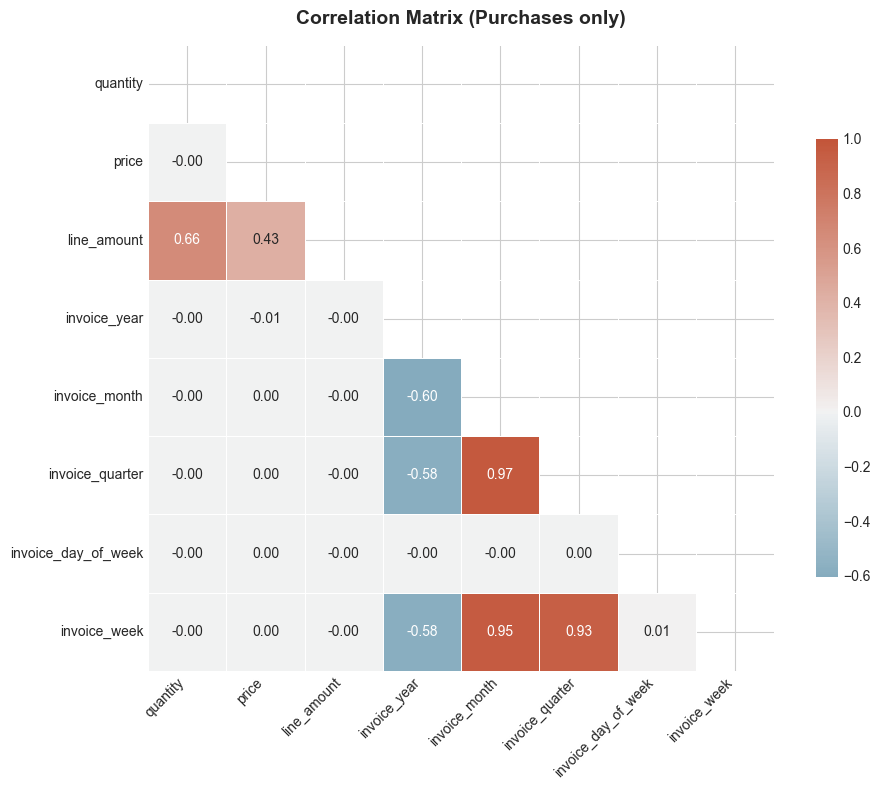


Highly correlated pairs (|r| > 0.7):
  invoice_month        ↔ invoice_quarter     : r = 0.969
  invoice_month        ↔ invoice_week        : r = 0.950
  invoice_quarter      ↔ invoice_week        : r = 0.928


In [10]:
# Only purchases to avoid cancellation noise
corr_cols = ['quantity', 'price', 'line_amount', 'invoice_year', 'invoice_month', 
             'invoice_quarter', 'invoice_day_of_week', 'invoice_week']

corr = purchases[corr_cols].corr()

# Masked heatmap
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=1.0, center=0,
            annot=True, fmt='.2f', square=True, linewidths=.5,
            cbar_kws={'shrink': .7}, annot_kws={'size': 10}, ax=ax)
ax.set_title('Correlation Matrix (Purchases only)', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# High correlation pairs
print("\nHighly correlated pairs (|r| > 0.7):")
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.7:
            print(f"  {corr.columns[i]:20s} ↔ {corr.columns[j]:20s}: r = {corr.iloc[i, j]:.3f}")

- `line_amount` ↔ `quantity` highly correlated (by construction: line_amount = qty × price)
- Calendar features naturally correlate (year ↔ quarter ↔ month)
- ML should use derived ratios (AOV, basket_size) instead of raw correlated features

### 9. Conclusions & Recommendations for Gold Layer

| Finding | Impact | Recommendation for Gold |
|---|---|---|
| Pipeline stable, drop rate <2% | High data trust | Proceed to build star schema |
| All quality checks pass | No data debt | dbt tests will pass |
| Right-skewed distributions | Aggregates sensitive to outliers | Use median-based quintiles for RFM |
| Strong seasonality | Churn patterns vary by cohort | Include temporal features in ML |
| ~25% anonymous transactions | Fact rows without customer | Route to customer_sk=0 |
| Calendar features accurate | Ready for join | dim_date join is clean |